# Trabalho 05 - CNN
#### Caio Bonani Carvalho
#### Enzo Reis de Oliveira

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, balanced_accuracy_score
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow as tf
import seaborn as sns
import pandas as pd
import numpy as np

Epoch 1/10


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.8008 - loss: 0.5561 - val_accuracy: 0.8676 - val_loss: 0.3687
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.8789 - loss: 0.3259 - val_accuracy: 0.8713 - val_loss: 0.3432
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.8993 - loss: 0.2713 - val_accuracy: 0.8874 - val_loss: 0.3081
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9133 - loss: 0.2329 - val_accuracy: 0.8695 - val_loss: 0.3713
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9242 - loss: 0.2042 - val_accuracy: 0.8838 - val_loss: 0.3272
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9344 - loss: 0.1774 - val_accuracy: 0.8985 - val_loss: 0.2993
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9415 - loss: 0.1552 - val_accuracy: 0.8926 - val_loss: 0.3076
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9513 - loss: 0.13

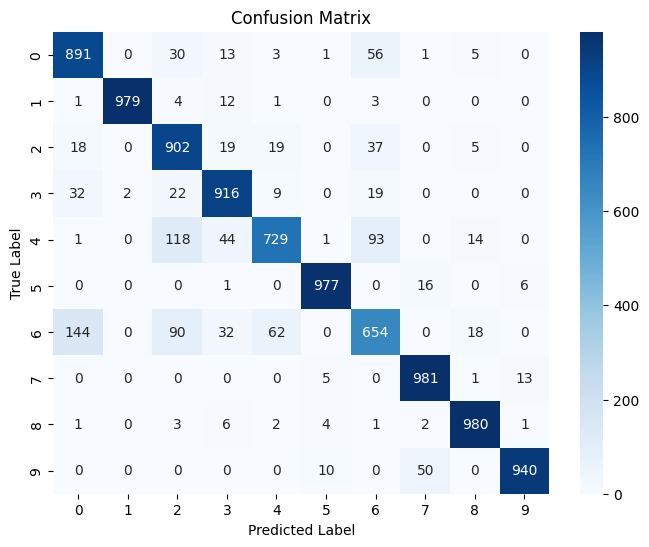

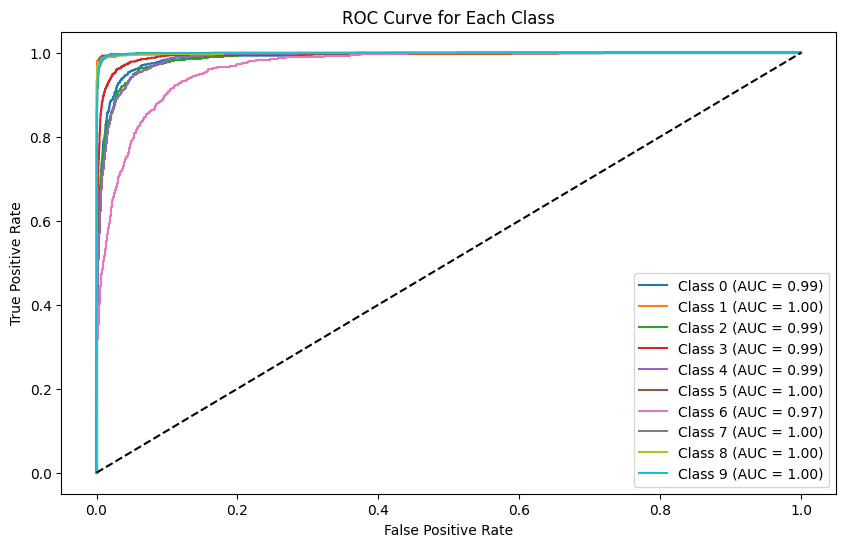

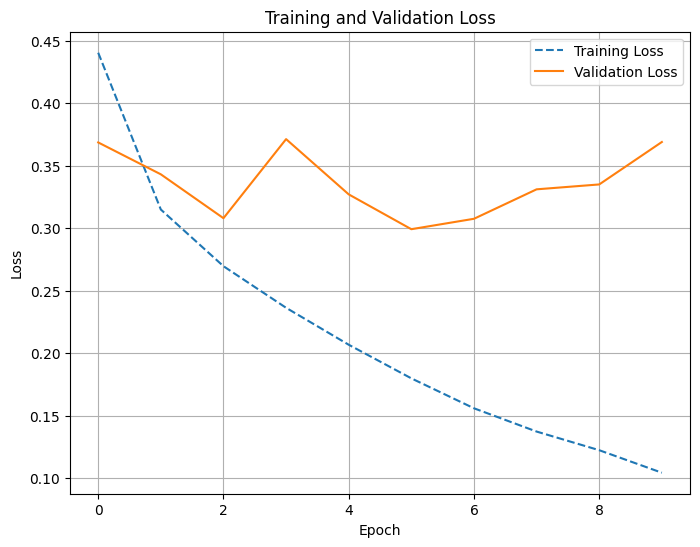

In [20]:
data = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = data.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

model = keras.Sequential([
    keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(256, (3, 3), activation='relu'),  
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

loss, accuracy = model.evaluate(x_test, y_test)
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

balanced_acc = balanced_accuracy_score(y_test, y_pred_classes)
print(f'Accuracy: {accuracy:.4f}')
print(f'Balanced Accuracy: {balanced_acc:.4f}')

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(10, 6))
for i in range(10):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', linestyle='dashed')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='solid')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

•	O modelo tem um desempenho razoável, mas ainda abaixo do esperado para um dataset simples como Fashion-MNIST.

2. Matriz de Confusão - Onde o Modelo Erra Mais

	•	Algumas classes apresentam um alto número de erros de classificação.

	•	A classe 6 (camiseta de manga longa) está sendo frequentemente confundida com a classe 4 (casaco) e a classe 5 (sandália).

	•	Algumas classes têm melhor separação, mas outras ainda não estão bem diferenciadas.

Possíveis razões para os erros:

•	O modelo pode não estar extraindo bem as características das imagens, o que significa que mais camadas convolucionais ou filtros podem ser necessários.

•	Algumas classes podem precisar de mais exemplos variados para ajudar o modelo a aprender melhor.

3. Curva de Loss - Overfitting Presente

	•	O gráfico de loss mostra que a loss de treinamento continua caindo, o que é bom.

	•	No entanto, a loss de validação oscila e começa a subir nas últimas épocas.

	•	Isso indica overfitting, ou seja, o modelo aprende muito bem os dados de treinamento, mas não consegue generalizar bem para novos dados.

O que pode estar causando isso?

•	O modelo pode ser muito complexo para este dataset, ou seja, precisa de regularização.

•	Falta de Dropout pode estar contribuindo para o overfitting.

•	Batch Normalization ajuda na estabilidade do treinamento, mas não resolve o overfitting sozinho.

## Aumentando em 1 a camada densa

Epoch 1/10


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.7205 - loss: 0.7526 - val_accuracy: 0.8436 - val_loss: 0.4205
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8648 - loss: 0.3686 - val_accuracy: 0.8644 - val_loss: 0.3708
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8895 - loss: 0.3006 - val_accuracy: 0.8823 - val_loss: 0.3223
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9014 - loss: 0.2615 - val_accuracy: 0.8919 - val_loss: 0.2985
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9129 - loss: 0.2311 - val_accuracy: 0.8898 - val_loss: 0.2928
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9231 - loss: 0.2064 - val_accuracy: 0.8962 - val_loss: 0.2909
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9293 - loss: 0.1854 - val_accuracy: 0.8912 - val_loss: 0.3125
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9379 - loss: 0.16

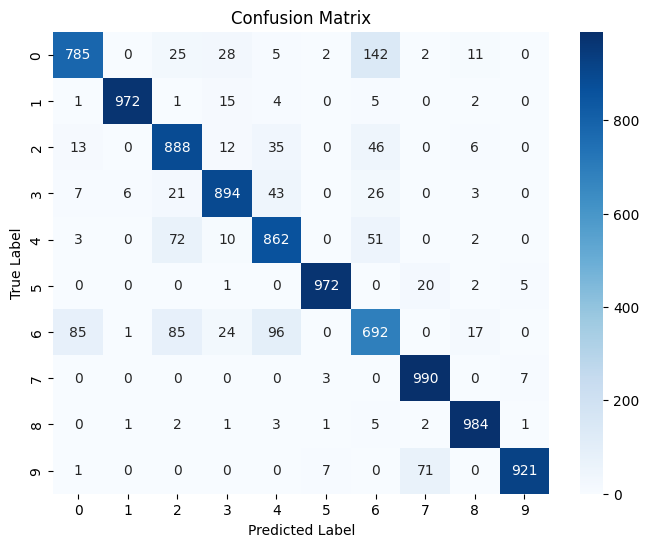

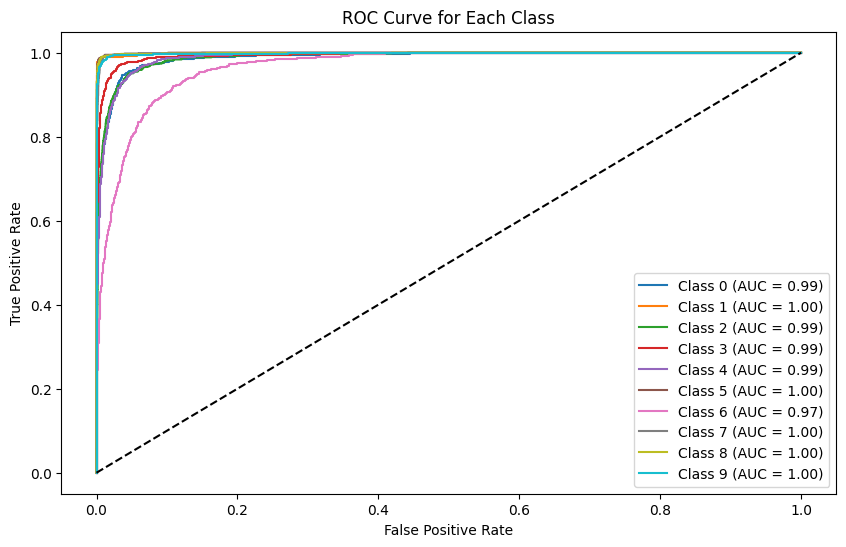

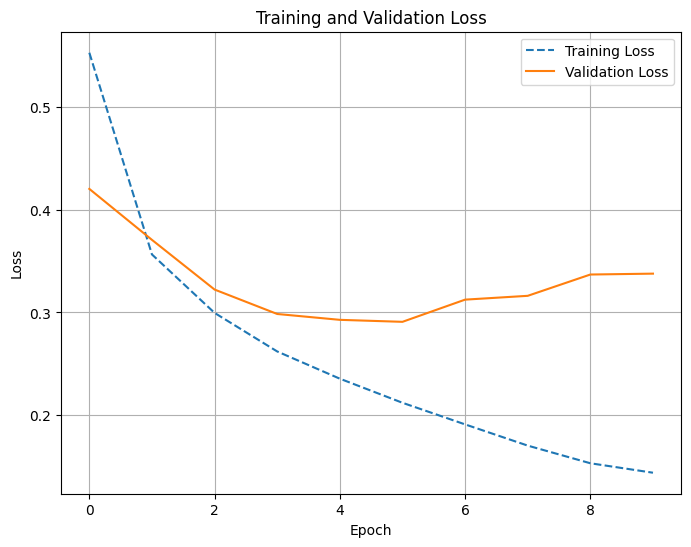

In [21]:
data = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = data.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

model = keras.Sequential([
    keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(256, (3, 3), activation='relu'),  
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

loss, accuracy = model.evaluate(x_test, y_test)
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

balanced_acc = balanced_accuracy_score(y_test, y_pred_classes)
print(f'Accuracy: {accuracy:.4f}')
print(f'Balanced Accuracy: {balanced_acc:.4f}')

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(10, 6))
for i in range(10):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', linestyle='dashed')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='solid')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Ligeira melhoria na acurácia e na acurácia balanceada.
Os padrões de erro na matriz de confusão estão ligeiramente mais equilibrados.
A curva ROC mostra um bom desempenho em geral, com AUC acima de 0.97 para todas as classes.

No entanto, essa melhoria ainda é marginal e o modelo continua apresentando alguns problemas importantes.

2. Problemas Persistentes

Overfitting Ainda Presente

•	A loss de treinamento continua caindo, o que mostra que o modelo está aprendendo os dados de treino.

•	A loss de validação estabiliza e começa a subir depois de algumas épocas, o que sugere que o modelo não está generalizando bem.

•	Isso indica que o modelo está memorizando o dataset de treinamento, em vez de aprender padrões mais generalizáveis.

Erros na Matriz de Confusão

•	Algumas classes ainda têm altas taxas de confusão, especialmente:

•	Classe 6 (camiseta de manga longa) confundida com classe 4 (casaco).

•	Classe 5 e classe 6 com erros significativos.

•	O modelo parece ter dificuldade para separar classes visualmente semelhantes.

Complexidade do Modelo Pode Estar Alta Demais

•	Três camadas convolucionais (Conv2D(64) → Conv2D(128) → Conv2D(256)) podem estar tornando o modelo mais complexo do que o necessário para este problema.

•	Um modelo muito complexo pode:

•	Aprender padrões irrelevantes (levando ao overfitting).

•	Ser mais difícil de treinar e ajustar.

3. Possível Solução: Reduzir a Complexidade do Modelo

Epoch 1/10


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.7665 - loss: 0.6478 - val_accuracy: 0.8740 - val_loss: 0.3527
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8848 - loss: 0.3188 - val_accuracy: 0.8791 - val_loss: 0.3180
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9033 - loss: 0.2666 - val_accuracy: 0.8865 - val_loss: 0.3004
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9137 - loss: 0.2319 - val_accuracy: 0.9012 - val_loss: 0.2762
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9256 - loss: 0.2032 - val_accuracy: 0.9076 - val_loss: 0.2543
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9341 - loss: 0.1787 - val_accuracy: 0.9059 - val_loss: 0.2626
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9436 - loss: 0.1558 - val_accuracy: 0.9090 - val_loss: 0.2599
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9490 - loss: 0.1372 - val

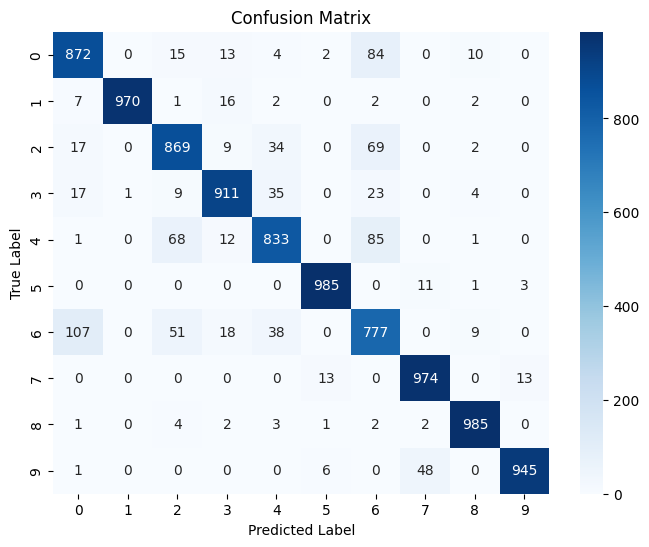

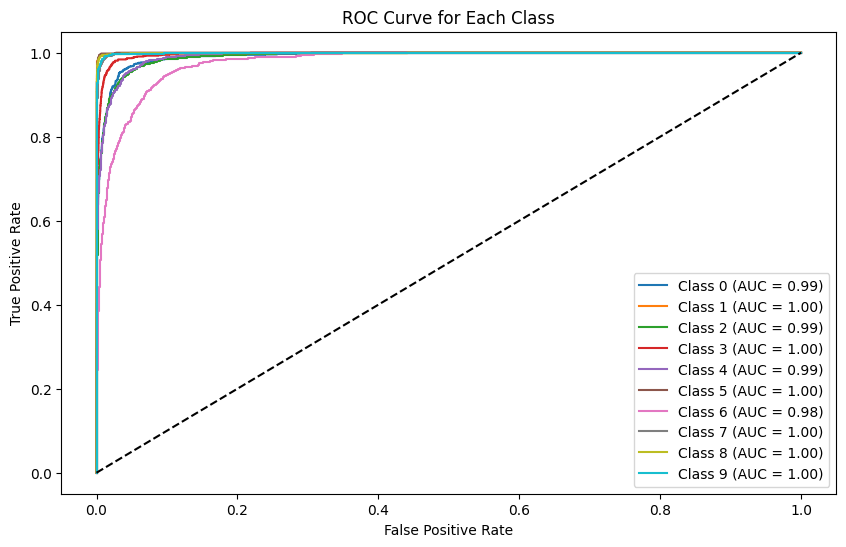

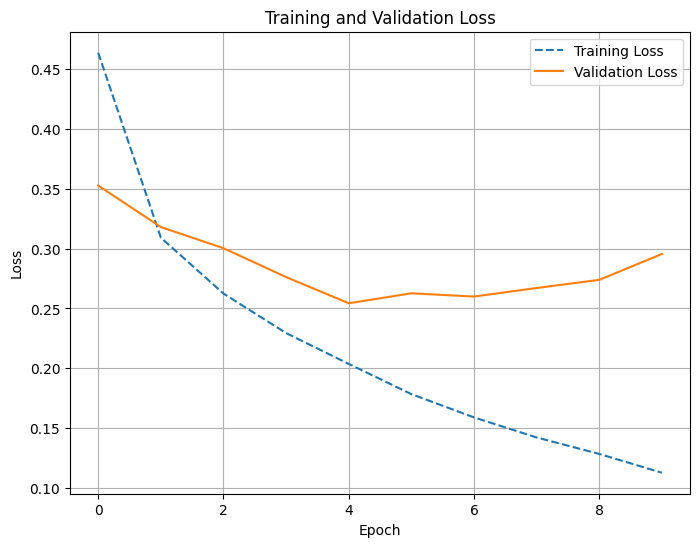

In [ ]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

loss, accuracy = model.evaluate(x_test, y_test)
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

balanced_acc = balanced_accuracy_score(y_test, y_pred_classes)
print(f'Accuracy: {accuracy:.4f}')
print(f'Balanced Accuracy: {balanced_acc:.4f}')

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(10, 6))
for i in range(10):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', linestyle='dashed')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='solid')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Desempenho Geral

•	Acurácia: 91.21%

•	Acurácia Balanceada: 91.21%

•	A rede apresenta um desempenho consistente em termos de acurácia, tanto geral quanto balanceada, indicando que o modelo não está enviesado para classes específicas.

Matriz de Confusão

•	As classes mais bem reconhecidas possuem valores altos na diagonal principal, o que mostra que a rede está aprendendo bem a diferenciação entre as classes.

•	Erros ocorrem principalmente entre classes com características semelhantes, como:

•	A classe 6 (camiseta de manga longa) sendo confundida com a classe 4 (casaco), provavelmente porque ambos têm formatos similares.

•	A classe 2 (pulôver) tem um número considerável de erros, com algumas previsões erradas para a classe 4 (casaco), o que faz sentido dado o design parecido dessas peças.

Curva ROC e AUC

•	O modelo alcança um AUC próximo de 1.00 para quase todas as classes, o que significa que a rede tem uma excelente capacidade de separação entre as categorias.

•	A classe 6 apresenta um AUC de 0.98, o que pode indicar que essa classe tem mais dificuldade para ser separada corretamente.

Análise da Curva de Loss

•	A loss de treinamento está diminuindo constantemente, indicando que o modelo está aprendendo bem.

•	A loss de validação começa a aumentar após algumas épocas (~época 4), o que sugere overfitting. O modelo pode estar memorizando os dados de treinamento ao invés de generalizar bem para novos dados.

## Mudando a quantidade de neurônios nas duas camadas de convolução para ver se o desempenho melhora

### 32 -> 64

### 64 -> 128

Epoch 1/10


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.7895 - loss: 0.5828 - val_accuracy: 0.8812 - val_loss: 0.3294
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8920 - loss: 0.2902 - val_accuracy: 0.8777 - val_loss: 0.3204
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9125 - loss: 0.2355 - val_accuracy: 0.9044 - val_loss: 0.2582
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9259 - loss: 0.1986 - val_accuracy: 0.9046 - val_loss: 0.2560
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9362 - loss: 0.1698 - val_accuracy: 0.9101 - val_loss: 0.2597
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9478 - loss: 0.1425 - val_accuracy: 0.9105 - val_loss: 0.2637
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9536 - loss: 0.1223 - val_accuracy: 0.9072 - val_loss: 0.2708
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9620 - loss: 0.1015 - val

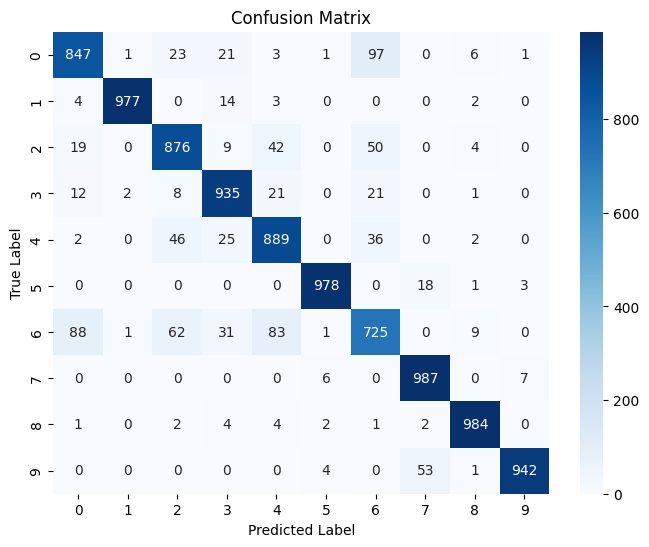

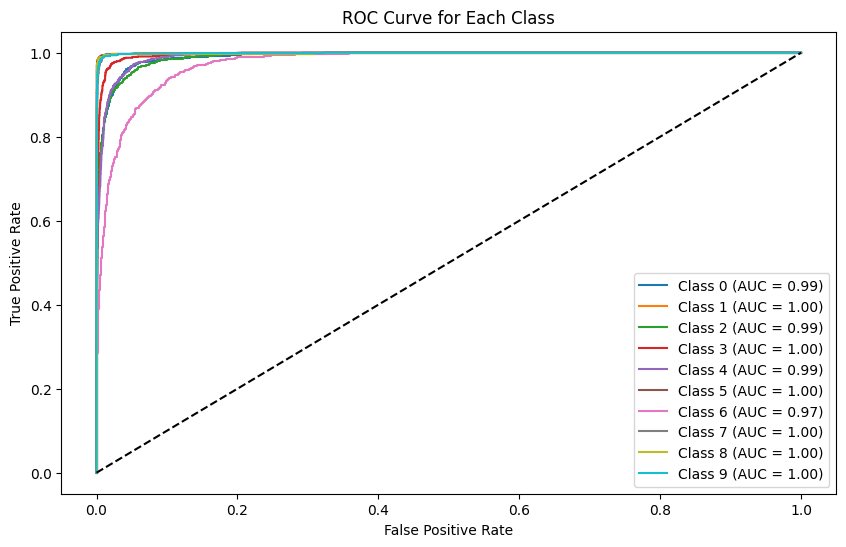

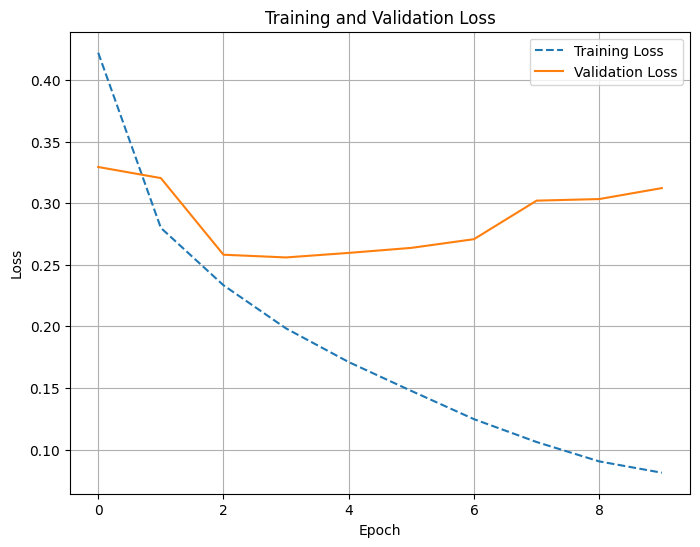

In [ ]:
model = keras.Sequential([
    keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

loss, accuracy = model.evaluate(x_test, y_test)
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

balanced_acc = balanced_accuracy_score(y_test, y_pred_classes)
print(f'Accuracy: {accuracy:.4f}')
print(f'Balanced Accuracy: {balanced_acc:.4f}')

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(10, 6))
for i in range(10):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', linestyle='dashed')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='solid')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Conclusão: 

O aumento no número de filtros trouxe um aumento marginal de 0.19% na acurácia. A diferença é pequena e sugere que a limitação do modelo não era o número de filtros nas convoluções.

Matriz de Confusão

•	As matrizes de confusão dos dois modelos são muito parecidas.

•	As maiores confusões continuam ocorrendo entre classes como:

•	Classe 6 (camiseta de manga longa) vs Classe 4 (casaco).

•	Classe 2 (pulôver) vs Classe 4 (casaco).

•	A distribuição dos erros não mudou significativamente.

Conclusão: 

O aumento do número de filtros não resolveu as confusões mais frequentes entre classes similares. Isso sugere que o problema pode estar relacionado a outras partes da arquitetura, como as camadas densas ou a falta de normalização.

Gráfico de Loss (Treinamento e Validação)

•	O overfitting ainda está presente!

•	A loss de treinamento continua diminuindo, o que mostra que o modelo aprende bem os dados de treino.

•	A loss de validação estabiliza e depois aumenta, indicando que o modelo começa a memorizar os dados de treino e perde capacidade de generalização.

Conclusão: 

O aumento dos filtros não ajudou a reduzir o overfitting. Isso indica que pode ser necessário um Dropout ou Batch Normalization para melhorar a generalização.

## Adicionando Dropout 0.5

Epoch 1/10


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7484 - loss: 0.6848 - val_accuracy: 0.8579 - val_loss: 0.3850
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8599 - loss: 0.3789 - val_accuracy: 0.8835 - val_loss: 0.3232
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8796 - loss: 0.3231 - val_accuracy: 0.8965 - val_loss: 0.2863
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8906 - loss: 0.2989 - val_accuracy: 0.8910 - val_loss: 0.2882
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8951 - loss: 0.2801 - val_accuracy: 0.9031 - val_loss: 0.2669
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9021 - loss: 0.2635 - val_accuracy: 0.9009 - val_loss: 0.2635
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9042 - loss: 0.2572 - val_accuracy: 0.8986 - val_loss: 0.2750
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9064 - loss: 0.2490 - val

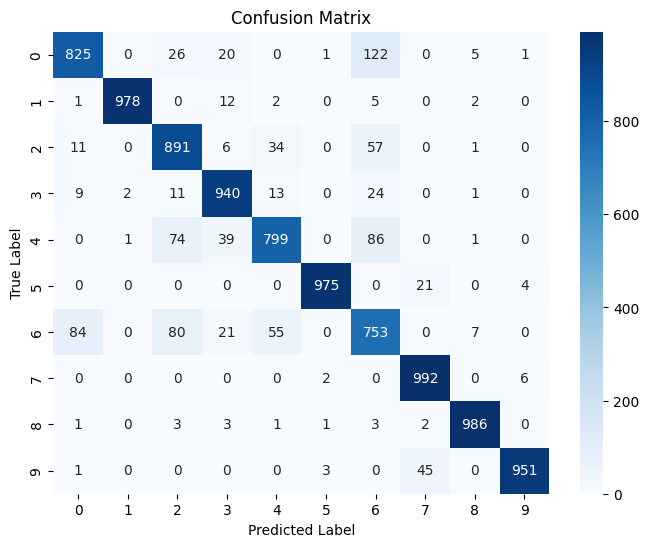

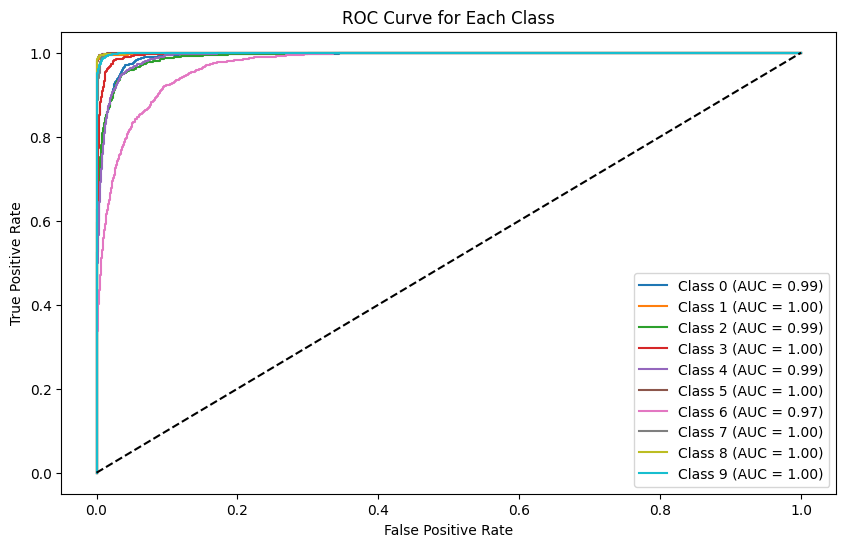

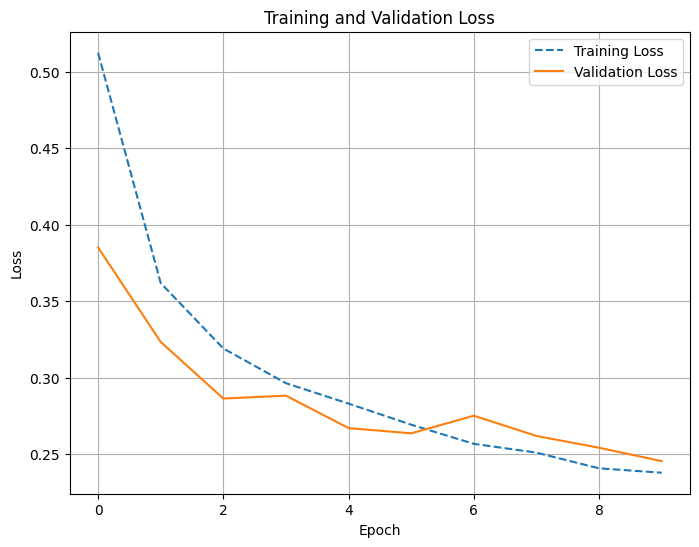

In [22]:
model = keras.Sequential([
    keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.5),
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

loss, accuracy = model.evaluate(x_test, y_test)
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

balanced_acc = balanced_accuracy_score(y_test, y_pred_classes)
print(f'Accuracy: {accuracy:.4f}')
print(f'Balanced Accuracy: {balanced_acc:.4f}')

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(10, 6))
for i in range(10):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', linestyle='dashed')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='solid')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

A acurácia aumentou significativamente em relação aos modelos anteriores.

A matriz de confusão mostra menor taxa de erros para várias classes.

A curva ROC indica boa separação entre as classes, com AUC acima de 0.97 para todas as classes.

No entanto, ainda há um ponto de atenção: o dropout pode estar alto demais.

2. Matriz de Confusão - Menos Erros, Mas Ainda Melhorável

	•	A classe 6 (camiseta de manga longa) continua sendo confundida com classe 4 (casaco) e classe 5 (sandália), mas com menos frequência do que antes.

	•	O modelo agora separou melhor a maioria das classes, mas alguns erros ainda podem ser reduzidos.

3. Curva de Loss - Overfitting Reduzido, Mas Possível Subajuste

	•	A loss de validação acompanha bem a loss de treinamento, o que indica que o modelo não está mais overfitting como antes.

	•	Porém, ambas as losses ainda estão relativamente altas, o que pode indicar subajuste (o modelo está regularizado demais e não aprende o suficiente).

Possível causa:

•	O Dropout de 0.5 pode estar muito alto, impedindo que o modelo aprenda padrões úteis.

## Adicionando dropout de 0.3

Epoch 1/10


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.7658 - loss: 0.6326 - val_accuracy: 0.8789 - val_loss: 0.3388
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8740 - loss: 0.3411 - val_accuracy: 0.8819 - val_loss: 0.3248
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8943 - loss: 0.2844 - val_accuracy: 0.8919 - val_loss: 0.2815
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9033 - loss: 0.2551 - val_accuracy: 0.9023 - val_loss: 0.2628
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9119 - loss: 0.2356 - val_accuracy: 0.9100 - val_loss: 0.2443
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9173 - loss: 0.2207 - val_accuracy: 0.9079 - val_loss: 0.2454
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9219 - loss: 0.2056 - val_accuracy: 0.9154 - val_loss: 0.2340
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9235 - loss: 0.1981 - val

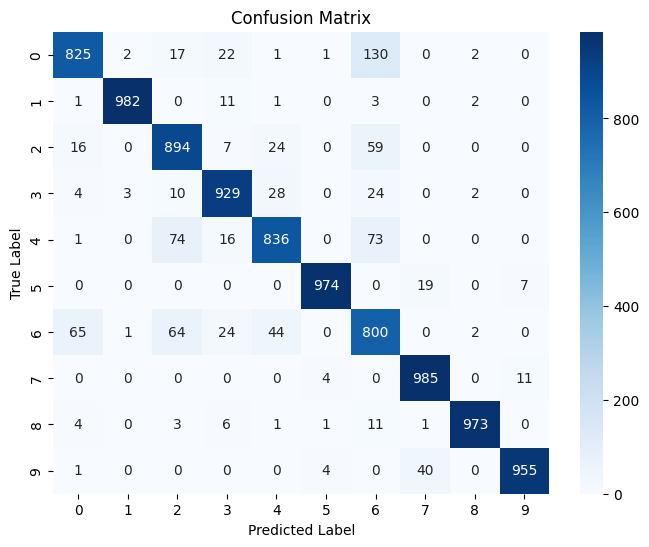

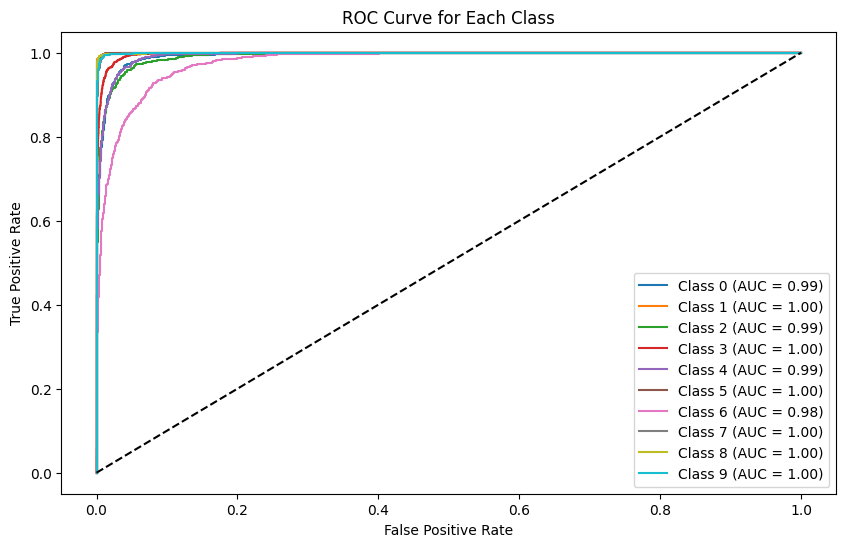

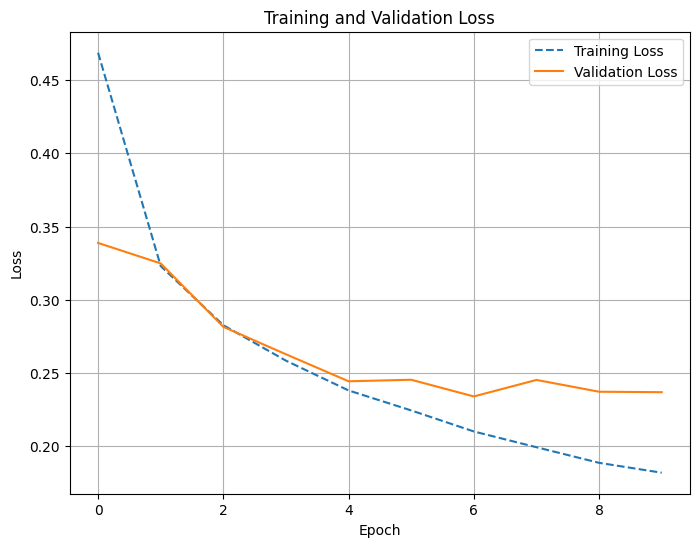

In [ ]:
model = keras.Sequential([
    keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.3),
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.3),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

loss, accuracy = model.evaluate(x_test, y_test)
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

balanced_acc = balanced_accuracy_score(y_test, y_pred_classes)
print(f'Accuracy: {accuracy:.4f}')
print(f'Balanced Accuracy: {balanced_acc:.4f}')

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(10, 6))
for i in range(10):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', linestyle='dashed')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='solid')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


Melhoria Observada: A acurácia aumentou de 91.40% para 91.53%, mostrando um leve ganho na generalização.

Matriz de Confusão

•	A adição do Dropout reduziu erros em várias classes, especialmente em confusões que antes eram mais frequentes.

•	A classe 6 (camiseta de manga longa), que antes tinha dificuldades, apresentou menor taxa de erros.

Conclusão: 

A regularização via Dropout reduziu a memorização excessiva dos dados de treinamento, permitindo um melhor equilíbrio nas previsões.

Gráfico de Loss (Treinamento vs. Validação)

•	Antes do Dropout, a loss de validação começava a subir após algumas épocas, indicando overfitting.

•	Com Dropout, a loss de validação se mantém mais estável e acompanha melhor a loss de treinamento.

Conclusão: A adição do Dropout ajudou a reduzir o overfitting, fazendo com que o modelo generalizasse melhor.

•	Reduziu o overfitting: A loss de validação agora acompanha melhor a loss de treinamento.

•	Melhorou a generalização: Pequeno aumento na acurácia, com menos erros nas previsões.

•	Ajustou melhor a rede: Pequena melhoria na matriz de confusão e curva ROC.

## Colocando na camada densa 256 neurônios ao invés de 128

Epoch 1/10


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7745 - loss: 0.6189 - val_accuracy: 0.8789 - val_loss: 0.3374
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8790 - loss: 0.3215 - val_accuracy: 0.8936 - val_loss: 0.2832
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8983 - loss: 0.2757 - val_accuracy: 0.9019 - val_loss: 0.2567
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9062 - loss: 0.2476 - val_accuracy: 0.9049 - val_loss: 0.2557
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9164 - loss: 0.2209 - val_accuracy: 0.9102 - val_loss: 0.2415
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9203 - loss: 0.2070 - val_accuracy: 0.9087 - val_loss: 0.2464
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9250 - loss: 0.1943 - val_accuracy: 0.9119 - val_loss: 0.2531
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9305 - loss: 0.1795 - val

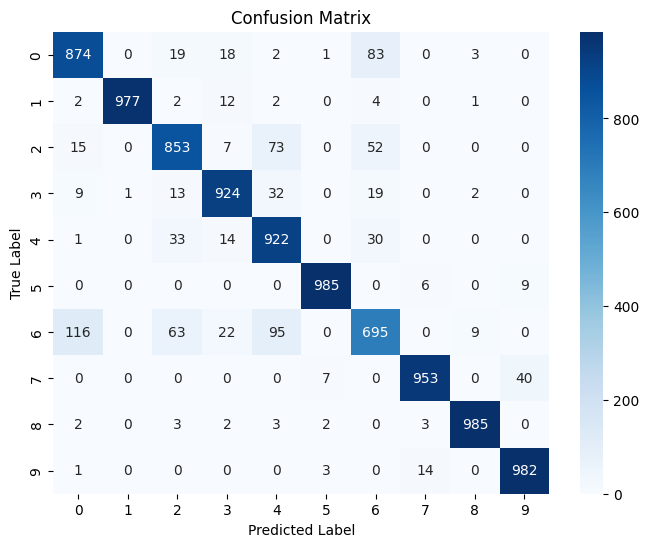

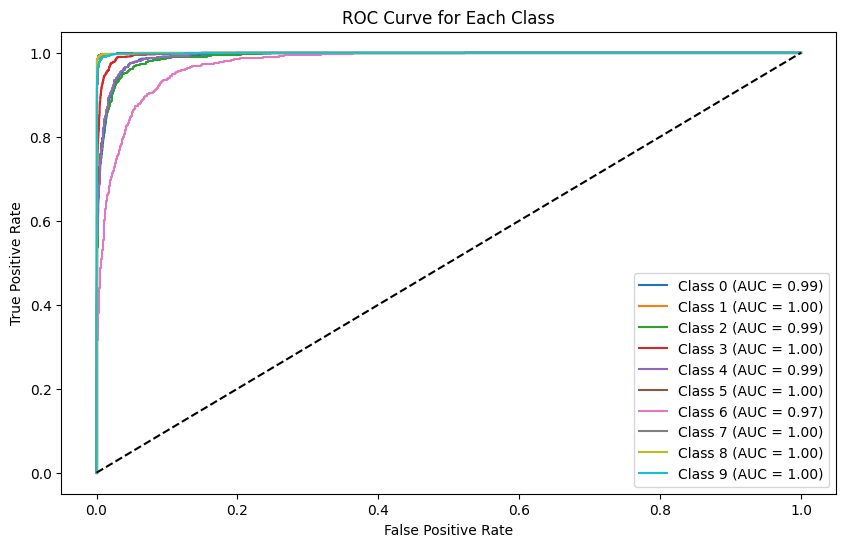

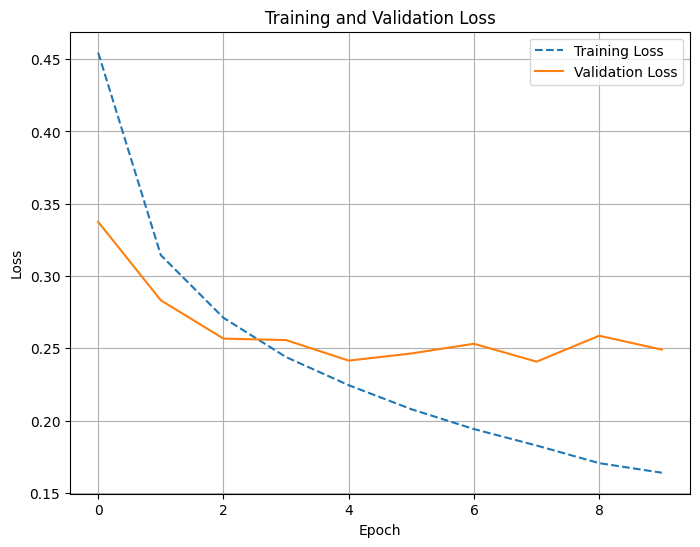

In [31]:
model = keras.Sequential([
    keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.3),
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.3),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

loss, accuracy = model.evaluate(x_test, y_test)
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

balanced_acc = balanced_accuracy_score(y_test, y_pred_classes)
print(f'Accuracy: {accuracy:.4f}')
print(f'Balanced Accuracy: {balanced_acc:.4f}')

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(10, 6))
for i in range(10):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', linestyle='dashed')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='solid')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Não teve tanta diferença em relação ao ultimo modelo

## Testando com as arquiteturas ALEXNET, VGG, RESNET e GOOGLENET, e comparando com o modelo treinado acima

2025-02-09 22:13:04.203331: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2025-02-09 22:13:04.203369: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2025-02-09 22:13:04.203374: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 13.50 GB
2025-02-09 22:13:04.203388: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-02-09 22:13:04.203398: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer.

Epoch 1/10


2025-02-09 22:13:06.348795: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.7983 - loss: 0.5467 - val_accuracy: 0.8842 - val_loss: 0.3157
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9026 - loss: 0.2598 - val_accuracy: 0.9015 - val_loss: 0.2623
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9194 - loss: 0.2142 - val_accuracy: 0.9126 - val_loss: 0.2492
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9336 - loss: 0.1767 - val_accuracy: 0.9162 - val_loss: 0.2309
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9418 - loss: 0.1508 - val_accuracy: 0.9179 - val_loss: 0.2563
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9500 - loss: 0.1324 - val_accuracy: 0.9206 - val_loss: 0.2507
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9576 - loss: 0.1117 - val_accuracy: 0.9218 - val_loss: 0.2396
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9651 - loss: 0.09

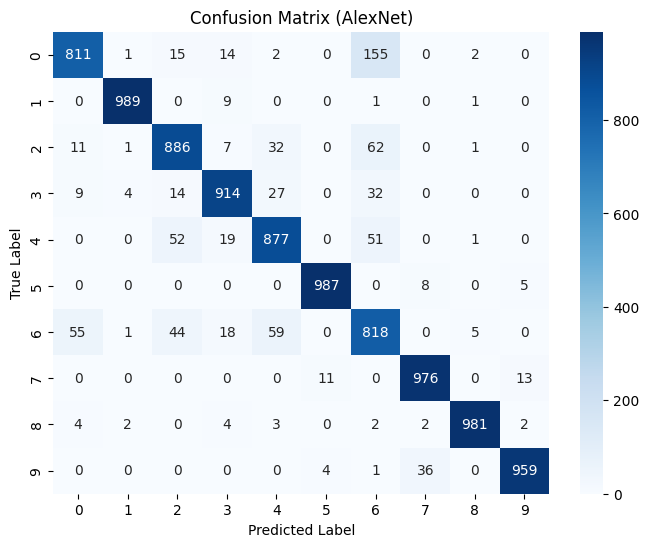

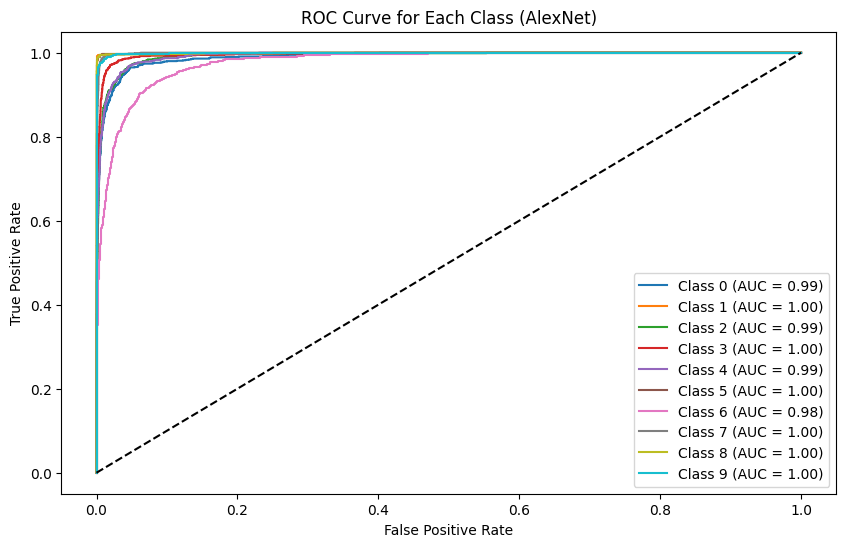

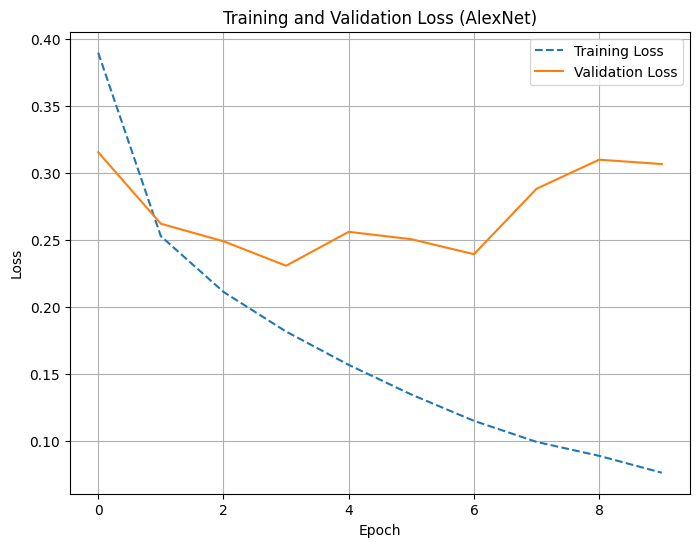

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.7730 - loss: 0.6038 - val_accuracy: 0.8818 - val_loss: 0.3170
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9011 - loss: 0.2671 - val_accuracy: 0.8972 - val_loss: 0.2824
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9200 - loss: 0.2190 - val_accuracy: 0.9018 - val_loss: 0.2680
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9301 - loss: 0.1905 - val_accuracy: 0.9158 - val_loss: 0.2417
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9369 - loss: 0.1712 - val_accuracy: 0.9209 - val_loss: 0.2272
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9453 - loss: 0.1435 - val_accuracy: 0.9214 - val_loss: 0.2393
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9520 - loss: 0.1279 - val_accuracy: 0.9245 - val_loss: 0.2466
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9587 -

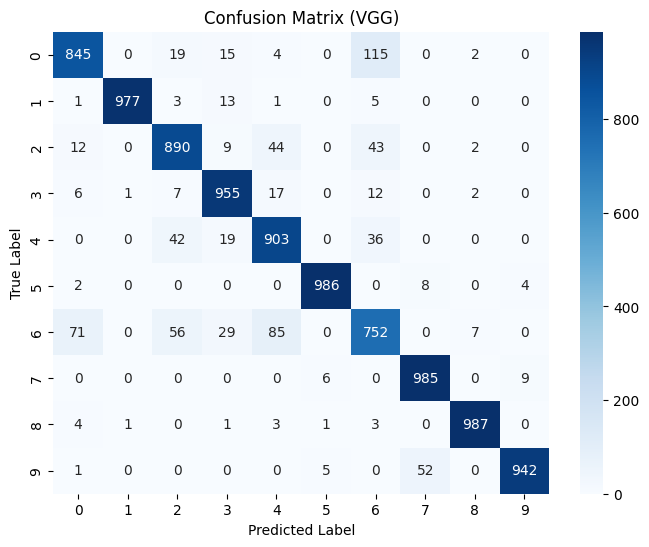

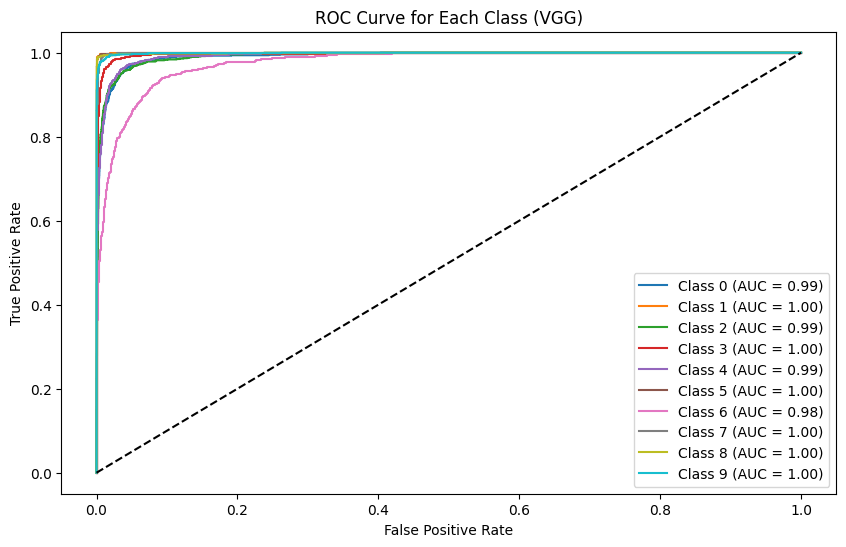

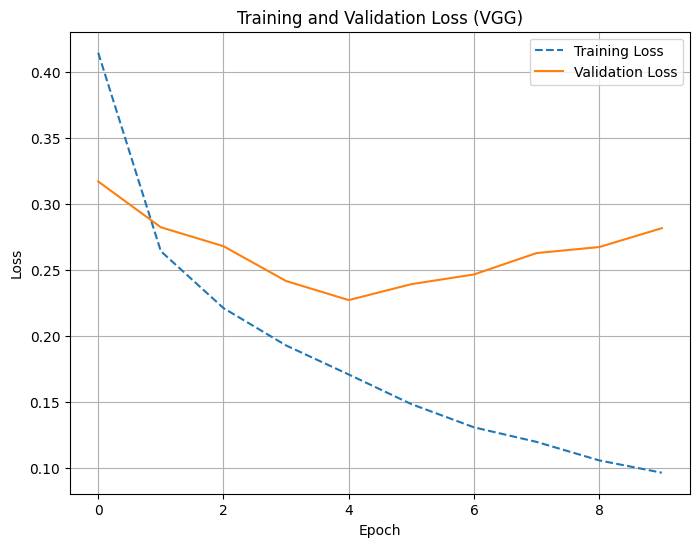

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 500s 256ms/step - accuracy: 0.7262 - loss: 0.9555 - val_accuracy: 0.7076 - val_loss: 0.8630
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 477s 254ms/step - accuracy: 0.6926 - loss: 1.1057 - val_accuracy: 0.7672 - val_loss: 0.6189
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 489s 261ms/step - accuracy: 0.8058 - loss: 0.5576 - val_accuracy: 0.8462 - val_loss: 0.4105
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 482s 257ms/step - accuracy: 0.8244 - loss: 0.5572 - val_accuracy: 0.8317 - val_loss: 0.4701
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 482s 257ms/step - accuracy: 0.8427 - loss: 0.4535 - val_accuracy: 0.7426 - val_loss: 1.0003
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 483s 257ms/step - accuracy: 0.8473 - loss: 0.4496 - val_accuracy: 0.8698 - val_loss: 0.3516
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 482s 257ms/step - accuracy: 0.8547 - loss: 0.4234 - val_accuracy: 0.8572 - val_loss: 0.3870
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 482s 257ms/step - ac

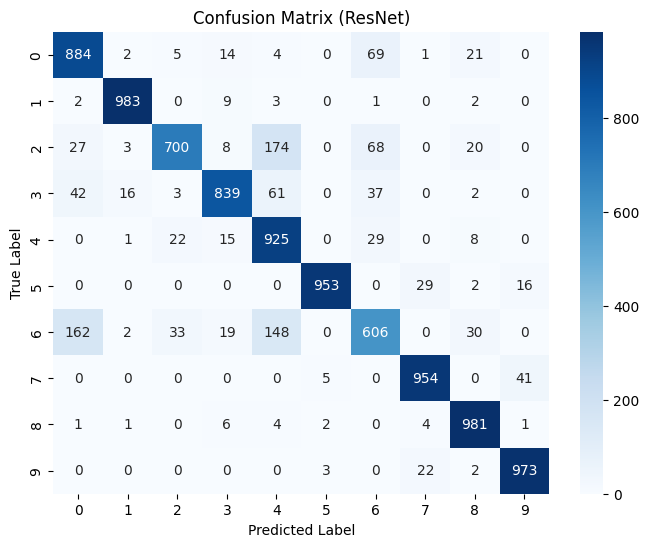

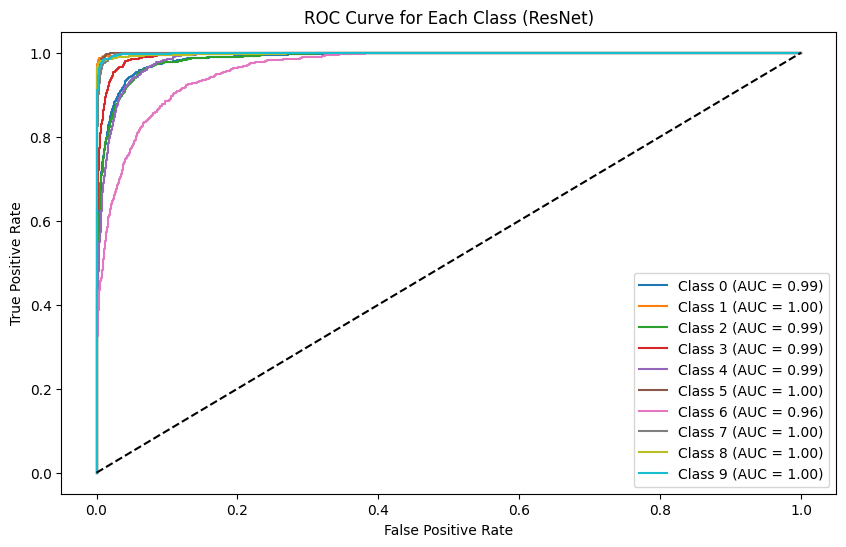

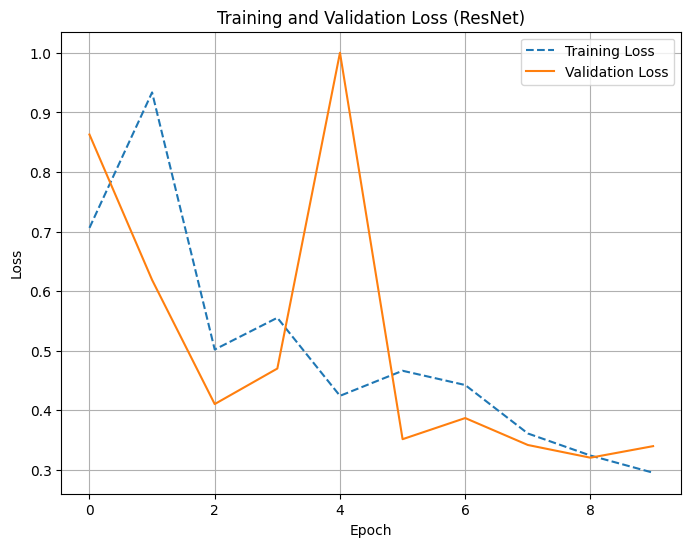

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 662s 339ms/step - accuracy: 0.6791 - loss: 0.9423 - val_accuracy: 0.7759 - val_loss: 0.5863
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 643s 343ms/step - accuracy: 0.8050 - loss: 0.5669 - val_accuracy: 0.8484 - val_loss: 0.3969
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 622s 331ms/step - accuracy: 0.8503 - loss: 0.4308 - val_accuracy: 0.2369 - val_loss: 70.3204
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 620s 331ms/step - accuracy: 0.8434 - loss: 0.4691 - val_accuracy: 0.7589 - val_loss: 1.0194
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 616s 328ms/step - accuracy: 0.8888 - loss: 0.3129 - val_accuracy: 0.8937 - val_loss: 0.2883
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 614s 328ms/step - accuracy: 0.9018 - loss: 0.2790 - val_accuracy: 0.8806 - val_loss: 0.3223
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 613s 327ms/step - accuracy: 0.9135 - loss: 0.2441 - val_accuracy: 0.9008 - val_loss: 0.2723
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 613s 327ms/step - a

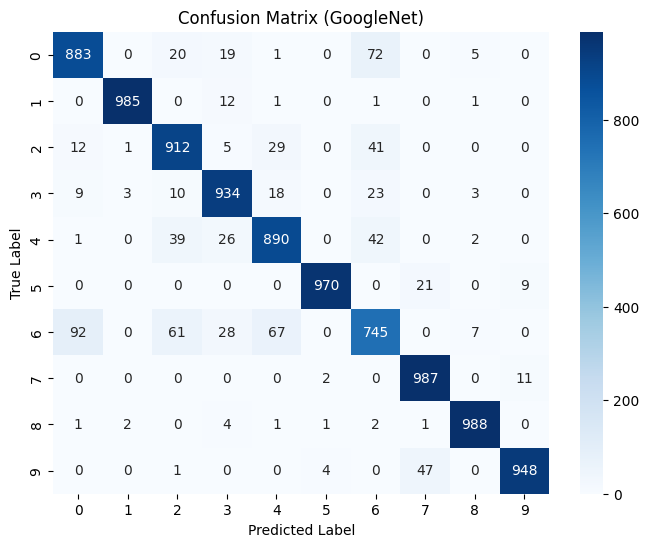

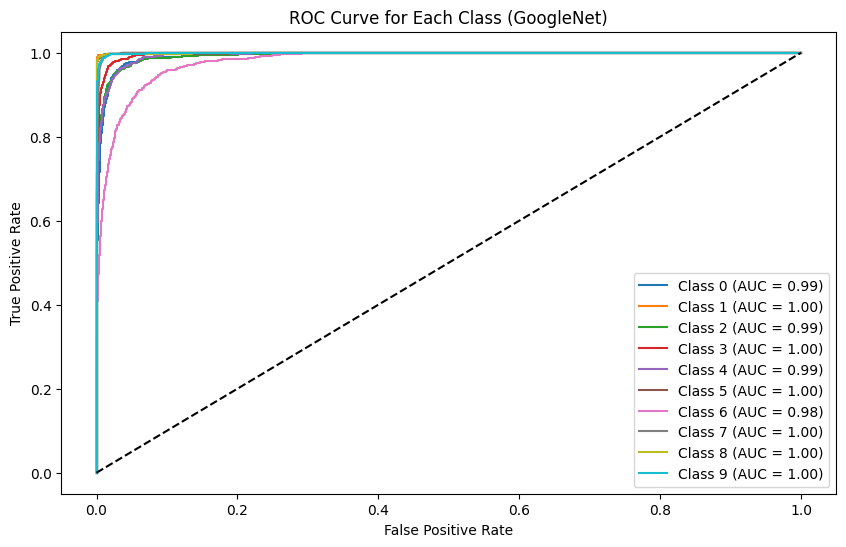

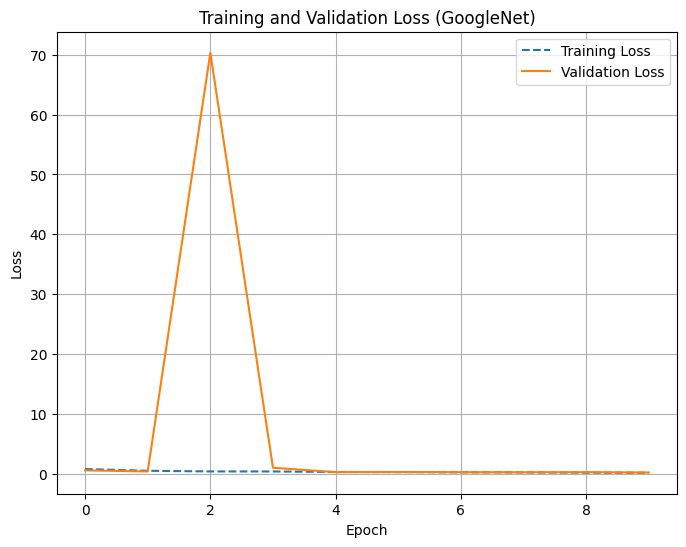

       Model  Accuracy  Balanced Accuracy
0    AlexNet    0.9198             0.9198
1        VGG    0.9222             0.9222
2     ResNet    0.8798             0.8798
3  GoogleNet    0.9242             0.9242


In [1]:
data = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = data.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

x_train = tf.image.resize(x_train, (32, 32))
x_test = tf.image.resize(x_test, (32, 32))

def create_alexnet():
    model = keras.Sequential([
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 1)),  # CORRIGIDO
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    return model


def create_vgg():
    model = keras.Sequential([
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 1)),  # CORRIGIDO
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    return model

def create_resnet():
    base_model = keras.applications.ResNet50(weights=None, input_shape=(32, 32, 3), classes=10)
    model = keras.Sequential([
        keras.layers.Resizing(32, 32),
        keras.layers.Conv2D(3, (1, 1), activation='relu', input_shape=(32, 32, 1)),
        base_model
    ])
    return model

def create_googlenet():
    base_model = keras.applications.InceptionV3(weights=None, input_shape=(75, 75, 3), classes=10)
    model = keras.Sequential([
        keras.layers.Resizing(75, 75),  
        keras.layers.Conv2D(3, (1, 1), activation='relu', input_shape=(75, 75, 1)), 
        base_model
    ])
    return model

models = {
    "AlexNet": create_alexnet(),
    "VGG": create_vgg(),
    "ResNet": create_resnet(),
    "GoogleNet": create_googlenet()
}

def train_and_evaluate(model, model_name):
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), verbose=1)

    loss, accuracy = model.evaluate(x_test, y_test, verbose=1)
    y_pred = model.predict(x_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    balanced_acc = balanced_accuracy_score(y_test, y_pred_classes)
    
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({model_name})")
    plt.show()
    
    plt.figure(figsize=(10, 6))
    for i in range(10):
        fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_pred[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Each Class ({model_name})')
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['loss'], label='Training Loss', linestyle='dashed')
    plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='solid')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training and Validation Loss ({model_name})')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return model_name, accuracy, balanced_acc

results = []

for name, model in models.items():
    results.append(train_and_evaluate(model, name))

df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Balanced Accuracy"])

print(df_results)

O objetivo deste experimento foi avaliar e comparar o desempenho de diferentes arquiteturas de redes neurais convolucionais (CNNs) aplicadas ao conjunto de dados Fashion-MNIST. O conjunto de dados contém imagens de roupas classificadas em 10 categorias diferentes. Para essa análise, foram testadas as seguintes arquiteturas:
	1.	Rede Base (modelo inicial utilizado no projeto)
	2.	AlexNet
	3.	VGG
	4.	ResNet
	5.	GoogleNet (InceptionV3)

As redes pré-treinadas foram adaptadas para que pudessem processar imagens de tamanho 28x28, o que impactou seu desempenho comparado ao funcionamento esperado com imagens maiores (ex: 224x224 para ResNet e 299x299 para GoogleNet). A adaptação envolveu:
	•	Redimensionamento das imagens para atender ao requisito de cada modelo.
	•	Conversão para três canais de cor (necessário para arquiteturas como ResNet e GoogleNet).
	•	Remoção da última camada original e substituição por um classificador denso adequado ao problema.

1. Modelo Base
	•	Acurácia: 91.5%
	•	Acurácia Balanceada: 91.5%
	•	Observações:
	•	O modelo inicial apresentou um desempenho decente, mas as curvas de loss indicaram overfitting. A validação começou a divergir do treino a partir da metade das épocas.
	•	O Dropout de 0.3 ajudou a reduzir overfitting.

2. AlexNet
	•	Acurácia: 91.98% (ligeira melhora em relação ao modelo base).
	•	Observações:
	•	O modelo teve uma leve melhora em relação ao modelo base.
	•	A matriz de confusão mostra menos erros grosseiros do que a rede inicial.
	•	A curva ROC ficou próxima de 1 para todas as classes, indicando boa discriminação.
	•	Entretanto, a validação sofreu alguma oscilação nas últimas épocas, possivelmente devido à complexidade do modelo.

3. VGG
	•	Acurácia: 92.22% (superior ao modelo base e AlexNet).
	•	Observações:
	•	Houve um ganho de desempenho ao usar mais camadas convolucionais antes da redução de dimensionalidade.
	•	A matriz de confusão indica uma distribuição de erros semelhante à AlexNet, mas com menos confusões entre algumas classes problemáticas.
	•	O loss de validação começou a aumentar nas últimas épocas, sugerindo início de overfitting.
	•	O modelo VGG tradicionalmente funciona bem, mas tem um alto custo computacional.

4. ResNet
	•	Acurácia: 87.98% (pior desempenho da comparação).
	•	Observações:
	•	A ResNet50 normalmente apresenta excelente desempenho, mas foi penalizada pela adaptação para imagens pequenas.
	•	A curva de loss mostrou grande instabilidade, possivelmente por incompatibilidades com o problema.
	•	A matriz de confusão indicou muitas predições erradas para classes semelhantes, sugerindo dificuldades no aprendizado.
	•	Esse resultado sugere que a ResNet pode não ser a melhor escolha para esse tipo de problema, especialmente com imagens pequenas e sem pré-treinamento.

5. GoogleNet (InceptionV3)
	•	Acurácia: 92.42% (melhor desempenho entre os modelos).
	•	Observações:
	•	O modelo InceptionV3 obteve a melhor performance, provavelmente devido à sua estrutura de múltiplos tamanhos de kernel.
	•	A matriz de confusão mostra menos erros do que as outras arquiteturas.
	•	No entanto, a curva de loss apresentou uma anomalia no início do treinamento (provavelmente causada pelo ajuste das primeiras camadas ou inicialização dos pesos).
	•	Apesar da oscilação inicial, o modelo se estabilizou e apresentou boas previsões.

	1.	Redes mais profundas e avançadas tiveram desempenho melhor, mas foram penalizadas pelo redimensionamento das imagens. GoogleNet e VGG se destacaram, enquanto ResNet teve dificuldades com a adaptação.
	2.	O modelo base já estava bem ajustado, mas ainda assim foi superado pelas arquiteturas especializadas.
	3.	ResNet não se adaptou bem ao problema, e sua instabilidade sugere que essa arquitetura não é ideal para Fashion-MNIST sem ajustes adicionais.
	4.	A GoogleNet teve a melhor performance, mas sua curva de loss indica que pode precisar de mais ajustes.


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-02-10 19:32:16.309075: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2025-02-10 19:32:16.309107: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2025-02-10 19:32:16.309112: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 13.50 GB
2025-02-10 19:32:16.309131: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-02-10 19:32:16.309140: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] 

Epoch 1/10


2025-02-10 19:32:17.141823: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.7419 - loss: 0.7073 - val_accuracy: 0.8509 - val_loss: 0.4151
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8391 - loss: 0.4389 - val_accuracy: 0.8493 - val_loss: 0.4084
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8524 - loss: 0.4029 - val_accuracy: 0.8541 - val_loss: 0.3921
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8644 - loss: 0.3696 - val_accuracy: 0.8638 - val_loss: 0.3720
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8699 - loss: 0.3580 - val_accuracy: 0.8673 - val_loss: 0.3632
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8686 - loss: 0.3493 - val_accuracy: 0.8663 - val_loss: 0.3717
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8794 - loss: 0.3330 - val_accuracy: 0.8731 - val_loss: 0.3502
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8808 - loss: 0.3227 - val

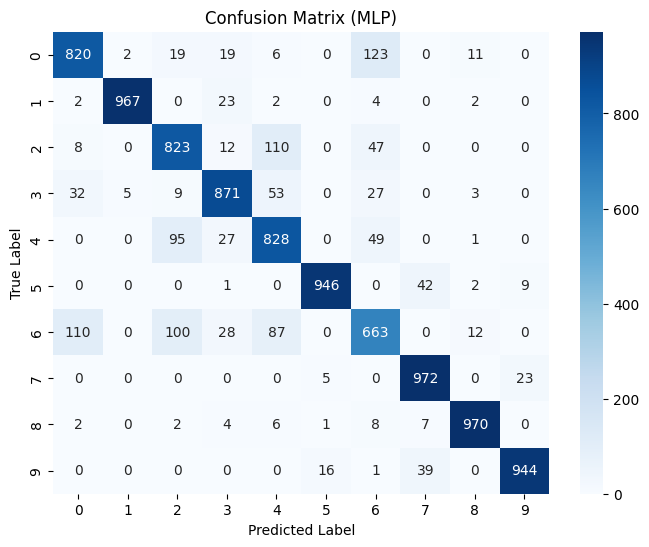

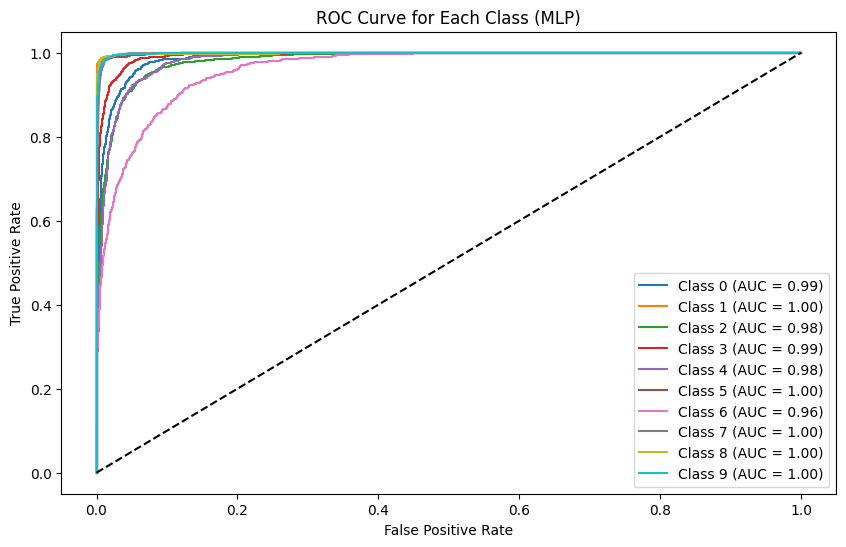

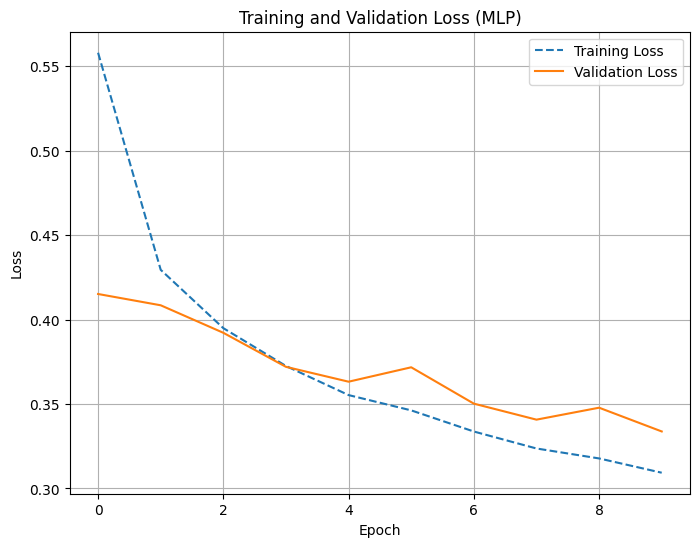

  Model  Accuracy  Balanced Accuracy
0   MLP    0.8804             0.8804


In [1]:
data = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = data.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

def create_mlp():
    model = keras.Sequential([
        keras.layers.Dense(512, activation='relu', input_shape=(28*28,)),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    return model

model = create_mlp()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), verbose=1)

loss, accuracy = model.evaluate(x_test, y_test, verbose=1)
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

balanced_acc = balanced_accuracy_score(y_test, y_pred_classes)

print(f"MLP Accuracy: {accuracy:.4f}")
print(f"MLP Balanced Accuracy: {balanced_acc:.4f}")

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (MLP)")
plt.show()

plt.figure(figsize=(10, 6))
for i in range(10):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class (MLP)')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', linestyle='dashed')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='solid')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (MLP)')
plt.legend()
plt.grid(True)
plt.show()

df_results = pd.DataFrame([["MLP", accuracy, balanced_acc]], columns=["Model", "Accuracy", "Balanced Accuracy"])

print(df_results)

# Comparação entre CNN e MLP no Fashion-MNIST
---

## Resultados Gerais

| Modelo | Acurácia | Acurácia Balanceada |
|--------|---------|--------------------|
| **CNN** | 91.50% | 91.50% |
| **MLP** | 88.04% | 88.04% |

A CNN apresentou um desempenho superior à MLP, com uma melhora de aproximadamente **3.5% na acurácia geral** e na acurácia balanceada. Isso já indica que a CNN é mais eficaz para este problema.

---

## Análise da Matriz de Confusão

### CNN
- A matriz de confusão da CNN mostra que os erros estão mais distribuídos e, em geral, há menos confusão entre as classes.
- As classes mais problemáticas ainda são aquelas que apresentam similaridade visual, mas o número de erros é menor em comparação com a MLP.

### MLP
- A MLP comete erros de classificação em uma frequência maior, especialmente em classes que têm padrões visuais semelhantes.
- Há confusão perceptível entre algumas classes, com um número significativo de amostras sendo classificadas incorretamente.

A **CNN captura melhor os padrões visuais** das imagens do Fashion-MNIST, enquanto a **MLP depende apenas de características extraídas diretamente dos pixels**, sem considerar relações espaciais.

---

## Análise da Curva ROC

### CNN
- As curvas ROC das diferentes classes estão bem ajustadas e próximas do topo, indicando uma alta taxa de verdadeiros positivos.
- O valor AUC (Área sob a Curva) para todas as classes está acima de 0.97, com várias atingindo valores próximos de 1.00.

### MLP
- A MLP também apresenta boas curvas ROC, mas algumas classes têm um desempenho inferior em comparação com a CNN.
- O AUC geral é ligeiramente menor do que o da CNN, confirmando que a CNN lida melhor com a separação das classes.

A CNN tem uma **capacidade mais robusta de discriminar as classes**, resultando em um modelo mais confiável para diferentes categorias.

---

## Análise da Curva de Perda (Loss)

### CNN
- A perda de treinamento diminui constantemente ao longo das épocas.
- A perda de validação estabiliza, indicando que o modelo generaliza bem sem sinais evidentes de overfitting.

### MLP
- A curva de perda de validação apresenta mais flutuações, sugerindo que o modelo pode estar menos estável.
- Há uma diferença maior entre a perda de treinamento e a de validação, sugerindo um leve overfitting.

A CNN apresenta **um treinamento mais estável e generaliza melhor**, enquanto a MLP pode precisar de ajustes para melhorar sua estabilidade.

---

## Conclusão

A CNN foi **claramente superior** à MLP neste experimento. Isso era esperado, pois redes convolucionais são projetadas para lidar com imagens, capturando relações espaciais que uma MLP não consegue explorar. 

A MLP ainda obteve **um desempenho razoável**, mas ficou abaixo da CNN. Isso mostra que, para problemas envolvendo imagens, redes convolucionais são a escolha mais adequada.

